# 02 - Python Data Processing

This notebook shows the Python part of the MedLine assignment step by step. It loads the dataset, cleans the data, checks quality, creates calculated fields, analyses service problems, and saves the required tables and charts for the report.

## 1. Setup

This cell installs and imports the Python libraries used for data processing, numerical calculations, tables and charts.

In [1]:
import sys
import subprocess
from pathlib import Path
import json
import warnings

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "pandas", "numpy", "matplotlib", "seaborn"],
    check=True,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
possible_data_dirs = [
    ROOT / "medline_resit_dataset",
    ROOT / "data",
    ROOT.parent / "medline_resit_dataset",
    ROOT.parent / "data",
]
DATA = next((path for path in possible_data_dirs if (path / "patients.csv").exists()), None)
if DATA is None:
    raise FileNotFoundError("Dataset folder not found. Upload medline_resit_dataset or data folder.")

PROJECT_ROOT = DATA.parent
OUT = PROJECT_ROOT / "outputs"
TABLES = OUT / "tables"
FIGURES = OUT / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("Required Python packages checked: pandas, numpy, matplotlib, seaborn")
print(f"Dataset folder found: {DATA.name}")

Required Python packages checked: pandas, numpy, matplotlib, seaborn
Dataset folder found: medline_resit_dataset


## 2. Load The Dataset

This cell loads every CSV file supplied in the MedLine dataset and shows a compact inventory of rows, columns and missing cells.

In [2]:
csv_files = {
    "patients": "patients.csv",
    "clinics": "clinics.csv",
    "staff": "staff.csv",
    "appointments": "appointments.csv",
    "referrals": "referrals.csv",
    "prescriptions": "prescriptions.csv",
    "nurse_visits": "nurse_visits.csv",
    "patient_feedback": "patient_feedback.csv",
    "digital_interactions": "digital_interactions.csv",
    "data_dictionary": "data_dictionary.csv",
}

dataframes = {name: pd.read_csv(DATA / filename) for name, filename in csv_files.items()}
patients = dataframes["patients"]
clinics = dataframes["clinics"]
staff = dataframes["staff"]
appointments = dataframes["appointments"]
referrals = dataframes["referrals"]
prescriptions = dataframes["prescriptions"]
nurse_visits = dataframes["nurse_visits"]
feedback = dataframes["patient_feedback"]
digital = dataframes["digital_interactions"]
data_dictionary = dataframes["data_dictionary"]

inventory_df = pd.DataFrame([
    {
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "missing_cells": int(df.isna().sum().sum()),
    }
    for name, df in dataframes.items()
])
inventory_df.to_csv(TABLES / "dataset_inventory.csv", index=False)
display(inventory_df)

,dataset,rows,columns,missing_cells
0,patients,250,7,98
1,clinics,6,6,0
2,staff,60,5,0
3,appointments,700,10,0
4,referrals,250,8,0
5,prescriptions,400,9,121
6,nurse_visits,300,9,147
7,patient_feedback,350,8,210
8,digital_interactions,719,10,0
9,data_dictionary,10,3,0


## 3. Clean Dates And Create Appointment Flags

This cell converts appointment date fields and creates `bad_outcome`, which is used for cancellations and no-shows.

In [3]:
for column in ["booking_datetime", "appointment_datetime"]:
    appointments[column] = pd.to_datetime(appointments[column])

appointments["bad_outcome"] = appointments["status"].isin([
    "Cancelled by patient",
    "Cancelled by clinic",
    "No-show",
])
appointments["appointment_month"] = appointments["appointment_datetime"].dt.to_period("M").astype(str)
appointments["booking_to_appointment_days"] = (
    appointments["appointment_datetime"] - appointments["booking_datetime"]
).dt.days

appointment_flag_check = appointments[[
    "appointment_id", "status", "waiting_days", "booking_to_appointment_days", "bad_outcome"
]].head(10)

display(appointment_flag_check)

,appointment_id,status,waiting_days,booking_to_appointment_days,bad_outcome
0,A00001,Rescheduled,23,23,False
1,A00002,Completed,16,16,False
2,A00003,Completed,11,11,False
3,A00004,Completed,16,16,False
4,A00005,Cancelled by patient,8,17,True
5,A00006,Completed,4,4,False
6,A00007,Cancelled by clinic,17,17,True
7,A00008,Completed,25,25,False
8,A00009,Cancelled by patient,4,9,True
9,A00010,Completed,14,14,False


## 4. Clean Referral, Prescription And Visit Dates

This cell prepares the delay-related fields for referrals, prescriptions and nurse visits.

In [4]:
referrals["created_date"] = pd.to_datetime(referrals["created_date"])
prescriptions["request_date"] = pd.to_datetime(prescriptions["request_date"])
prescriptions["processed_date"] = pd.to_datetime(prescriptions["processed_date"])
prescriptions["collection_date"] = pd.to_datetime(prescriptions["collection_date"], errors="coerce")
nurse_visits["scheduled_datetime"] = pd.to_datetime(nurse_visits["scheduled_datetime"])
feedback["complaint_flag"] = feedback["complaint_flag"].astype(bool)

referrals["delayed_or_open"] = referrals["referral_status"].isin(["Open", "Delayed"])
prescriptions["delayed_prescription"] = prescriptions["processing_days"] > 3
nurse_visits["problem_visit"] = nurse_visits["visit_status"].ne("Completed") | nurse_visits["follow_up_required"].fillna(False)

prepared_counts = pd.DataFrame({
    "prepared_area": ["referrals", "prescriptions", "nurse_visits", "feedback"],
    "rows": [len(referrals), len(prescriptions), len(nurse_visits), len(feedback)],
    "main_flag": ["delayed_or_open", "delayed_prescription", "problem_visit", "complaint_flag"],
})
display(prepared_counts)

,prepared_area,rows,main_flag
0,referrals,250,delayed_or_open
1,prescriptions,400,delayed_prescription
2,nurse_visits,300,problem_visit
3,feedback,350,complaint_flag


## 5. Data Quality Checks

This cell checks duplicates, invalid key links and date logic before the analysis results are used.

In [5]:
quality_checks = []

def add_check(check, failed_count):
    quality_checks.append({"check": check, "failed_count": int(failed_count)})

add_check("Duplicate appointment_id", appointments["appointment_id"].duplicated().sum())
add_check("Duplicate patient_id", patients["patient_id"].duplicated().sum())
add_check("Appointments with unknown patient_id", (~appointments["patient_id"].isin(patients["patient_id"])).sum())
add_check("Appointments with unknown clinic_id", (~appointments["clinic_id"].isin(clinics["clinic_id"])).sum())
add_check("Feedback with unknown appointment_id", (~feedback["appointment_id"].isin(appointments["appointment_id"])).sum())
add_check("Referrals with unknown appointment_id", (~referrals["appointment_id"].isin(appointments["appointment_id"])).sum())
add_check("Negative waiting_days", (appointments["waiting_days"] < 0).sum())
add_check("Prescription processed before request", (prescriptions["processed_date"] < prescriptions["request_date"]).sum())

quality_df = pd.DataFrame(quality_checks)
quality_df.to_csv(TABLES / "data_quality_checks.csv", index=False)
display(quality_df)

,check,failed_count
0,Duplicate appointment_id,0
1,Duplicate patient_id,0
2,Appointments with unknown patient_id,0
3,Appointments with unknown clinic_id,0
4,Feedback with unknown appointment_id,0
5,Referrals with unknown appointment_id,0
6,Negative waiting_days,0
7,Prescription processed before request,0


## 6. Appointment Status Distribution

This cell shows the appointment status table first, then the chart directly below it so the output is easy to follow.

,status,appointments,percentage
0,Completed,427,61.00
1,Cancelled by patient,86,12.29
2,Cancelled by clinic,83,11.86
3,Rescheduled,53,7.57
4,No-show,51,7.29


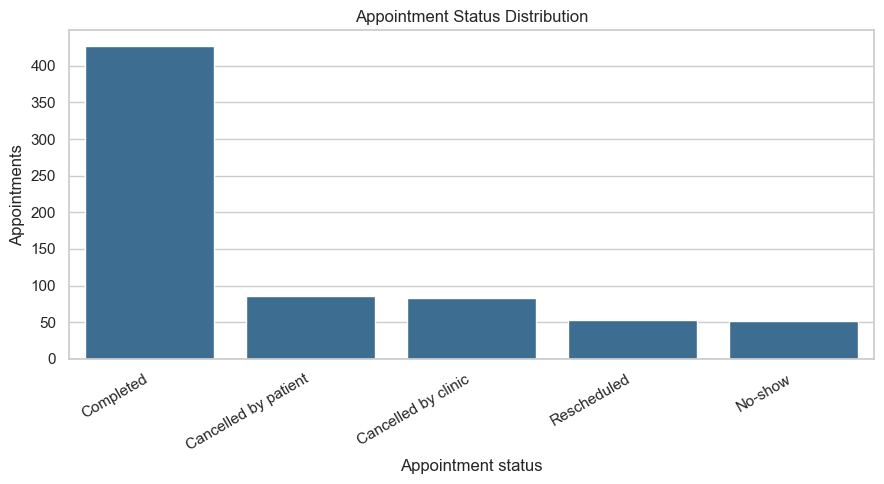

In [6]:
status_distribution = (
    appointments["status"].value_counts()
    .rename_axis("status")
    .reset_index(name="appointments")
)
status_distribution["percentage"] = status_distribution["appointments"] / len(appointments) * 100
status_distribution.to_csv(TABLES / "appointment_status_distribution.csv", index=False)

display(status_distribution.round(2))

plt.figure(figsize=(9, 5))
sns.barplot(data=status_distribution, x="status", y="appointments", color="#2f6f9f")
plt.title("Appointment Status Distribution")
plt.xlabel("Appointment status")
plt.ylabel("Appointments")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "appointment_status_distribution.png", dpi=150)
plt.show()

## 7. Waiting Days Distribution

This cell summarises appointment waiting days and shows the distribution. This is needed because waiting time is one of the main problems in the MedLine case study.

,statistic,waiting_days
0,count,700.00
1,mean,12.82
2,std,7.94
3,min,0.00
4,25%,6.00
5,50%,12.00
6,75%,19.00
7,max,28.00


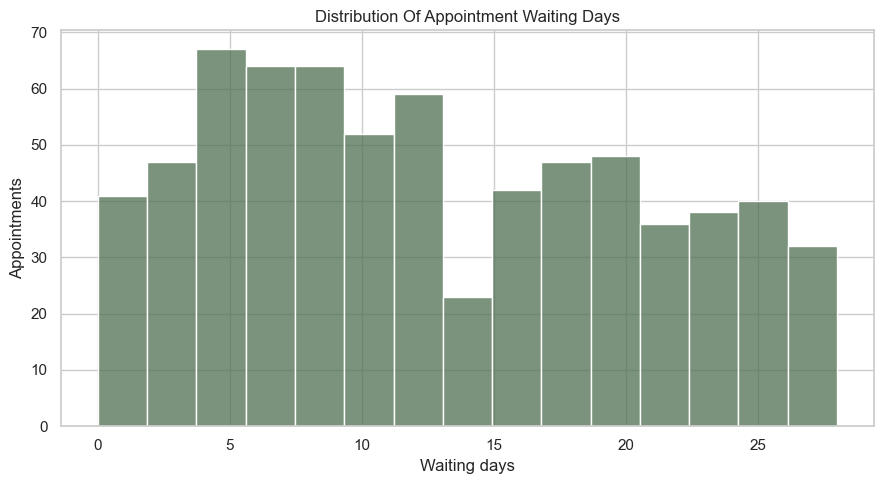

In [7]:
waiting_summary = appointments["waiting_days"].describe().reset_index()
waiting_summary.columns = ["statistic", "waiting_days"]
waiting_summary.to_csv(TABLES / "waiting_days_summary.csv", index=False)

display(waiting_summary.round(2))

plt.figure(figsize=(9, 5))
sns.histplot(data=appointments, x="waiting_days", bins=15, color="#4f6f52")
plt.title("Distribution Of Appointment Waiting Days")
plt.xlabel("Waiting days")
plt.ylabel("Appointments")
plt.tight_layout()
plt.savefig(FIGURES / "waiting_days_distribution.png", dpi=150)
plt.show()

## 8. Appointment Outcomes By Clinic

This cell calculates the clinic-level bad outcome table and immediately visualises the same result.

,clinic_id,clinic_name,appointments,bad_outcomes,avg_waiting_days,avg_duration_min,bad_outcome_rate
5,CL006,Canal Walk Clinic,127,52,13.09,33.23,40.94
0,CL001,Riverside Clinic,127,46,12.56,33.74,36.22
2,CL003,Northgate Diagnostics,130,41,12.02,35.54,31.54
1,CL002,Green Park Health Centre,96,27,13.80,34.53,28.12
3,CL004,Westbridge Community Clinic,117,32,12.32,36.03,27.35
4,CL005,Hillview Medical Hub,103,22,13.48,34.56,21.36


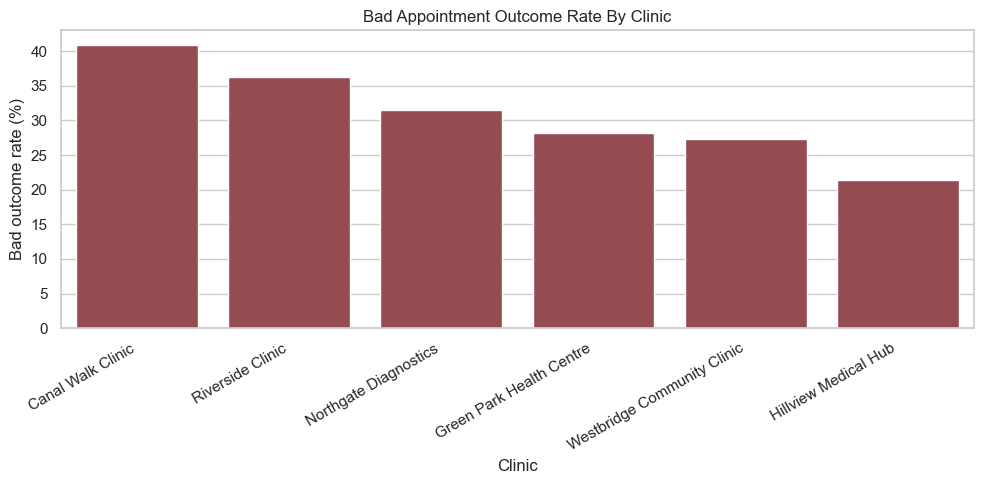

In [8]:
appointment_clinic = appointments.merge(clinics, on="clinic_id", how="left")

clinic_performance = (
    appointment_clinic.groupby(["clinic_id", "clinic_name"], as_index=False)
    .agg(
        appointments=("appointment_id", "count"),
        bad_outcomes=("bad_outcome", "sum"),
        avg_waiting_days=("waiting_days", "mean"),
        avg_duration_min=("appointment_duration_min", "mean"),
    )
)
clinic_performance["bad_outcome_rate"] = clinic_performance["bad_outcomes"] / clinic_performance["appointments"] * 100
clinic_performance = clinic_performance.sort_values("bad_outcome_rate", ascending=False)
clinic_performance.to_csv(TABLES / "clinic_appointment_performance.csv", index=False)

display(clinic_performance.round(2))

plt.figure(figsize=(10, 5))
sns.barplot(data=clinic_performance, x="clinic_name", y="bad_outcome_rate", color="#a23e48")
plt.title("Bad Appointment Outcome Rate By Clinic")
plt.xlabel("Clinic")
plt.ylabel("Bad outcome rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "bad_outcome_by_clinic.png", dpi=150)
plt.show()

## 9. Appointment Outcomes By Service

This cell checks which service type has the highest bad appointment outcome rate and shows the matching chart below the table.

,service_type,appointments,bad_outcomes,avg_waiting_days,bad_outcome_rate
5,Prescription Review,126,43,11.37,34.13
2,Diagnostic Scan,123,40,13.01,32.52
4,Nurse Appointment,117,37,12.57,31.62
0,Blood Test,111,34,13.53,30.63
1,Community Follow-up,119,36,13.32,30.25
3,GP Consultation,104,30,13.32,28.85


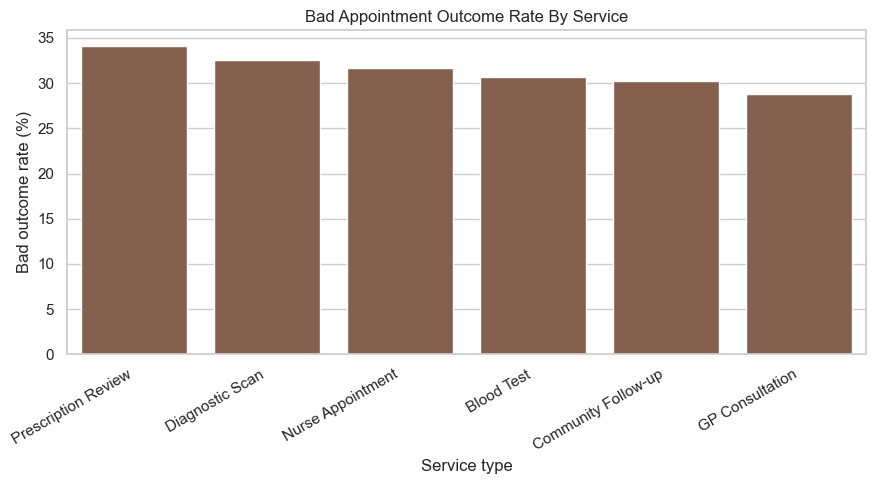

In [9]:
service_performance = (
    appointments.groupby("service_type", as_index=False)
    .agg(
        appointments=("appointment_id", "count"),
        bad_outcomes=("bad_outcome", "sum"),
        avg_waiting_days=("waiting_days", "mean"),
    )
)
service_performance["bad_outcome_rate"] = service_performance["bad_outcomes"] / service_performance["appointments"] * 100
service_performance = service_performance.sort_values("bad_outcome_rate", ascending=False)
service_performance.to_csv(TABLES / "service_appointment_performance.csv", index=False)

display(service_performance.round(2))

plt.figure(figsize=(9, 5))
sns.barplot(data=service_performance, x="service_type", y="bad_outcome_rate", color="#8f5d46")
plt.title("Bad Appointment Outcome Rate By Service")
plt.xlabel("Service type")
plt.ylabel("Bad outcome rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "bad_outcome_by_service.png", dpi=150)
plt.show()

## 10. Patient Feedback By Appointment Status

This cell compares patient ratings and complaint rates by appointment status, then shows the rating chart below the table.

,status,feedback_count,avg_rating,complaint_count,avg_waiting_days,complaint_rate
3,No-show,28,2.04,28,12.79,100.0
4,Rescheduled,22,2.23,22,13.41,100.0
0,Cancelled by clinic,45,2.27,45,14.42,100.0
1,Cancelled by patient,48,2.62,48,5.58,100.0
2,Completed,207,3.56,207,12.41,100.0


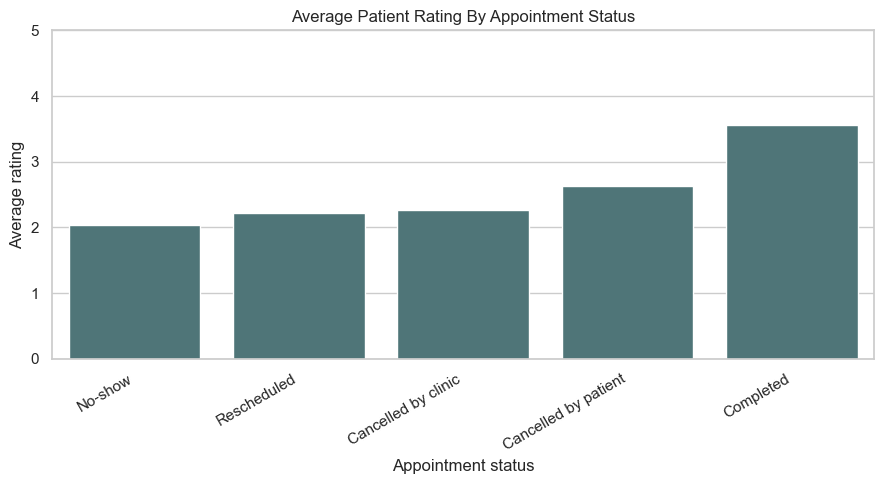

In [10]:
feedback_joined = (
    feedback.merge(appointments[["appointment_id", "status", "waiting_days", "service_type"]], on="appointment_id", how="left")
    .merge(clinics[["clinic_id", "clinic_name"]], on="clinic_id", how="left")
)

feedback_by_status = (
    feedback_joined.groupby("status", as_index=False)
    .agg(
        feedback_count=("feedback_id", "count"),
        avg_rating=("rating", "mean"),
        complaint_count=("complaint_flag", "sum"),
        avg_waiting_days=("waiting_days", "mean"),
    )
)
feedback_by_status["complaint_rate"] = feedback_by_status["complaint_count"] / feedback_by_status["feedback_count"] * 100
feedback_by_status = feedback_by_status.sort_values("avg_rating")
feedback_by_status.to_csv(TABLES / "feedback_by_status.csv", index=False)

display(feedback_by_status.round(2))

plt.figure(figsize=(9, 5))
sns.barplot(data=feedback_by_status, x="status", y="avg_rating", color="#487b7f")
plt.title("Average Patient Rating By Appointment Status")
plt.xlabel("Appointment status")
plt.ylabel("Average rating")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig(FIGURES / "rating_by_status.png", dpi=150)
plt.show()

## 11. Patient Feedback By Clinic

This cell checks whether any clinic has weaker patient satisfaction or higher complaint rates.

In [11]:
feedback_by_clinic = (
    feedback_joined.groupby(["clinic_id", "clinic_name"], as_index=False)
    .agg(
        feedback_count=("feedback_id", "count"),
        avg_rating=("rating", "mean"),
        complaints=("complaint_flag", "sum"),
        avg_waiting_days=("waiting_days", "mean"),
    )
)
feedback_by_clinic["complaint_rate"] = feedback_by_clinic["complaints"] / feedback_by_clinic["feedback_count"] * 100
feedback_by_clinic = feedback_by_clinic.sort_values("complaint_rate", ascending=False)
feedback_by_clinic.to_csv(TABLES / "feedback_by_clinic.csv", index=False)
display(feedback_by_clinic.round(2))

,clinic_id,clinic_name,feedback_count,avg_rating,complaints,avg_waiting_days,complaint_rate
0,CL001,Riverside Clinic,64,3.23,64,10.28,100.0
1,CL002,Green Park Health Centre,51,3.02,51,13.45,100.0
2,CL003,Northgate Diagnostics,75,3.01,75,11.76,100.0
3,CL004,Westbridge Community Clinic,55,3.13,55,11.65,100.0
4,CL005,Hillview Medical Hub,42,3.21,42,12.81,100.0
5,CL006,Canal Walk Clinic,63,2.79,63,11.65,100.0


## 12. Waiting Time And Rating Relationship

This cell calculates whether longer waiting times are linked with lower patient ratings.

,metric,value
0,waiting_days_vs_rating_correlation,-0.291


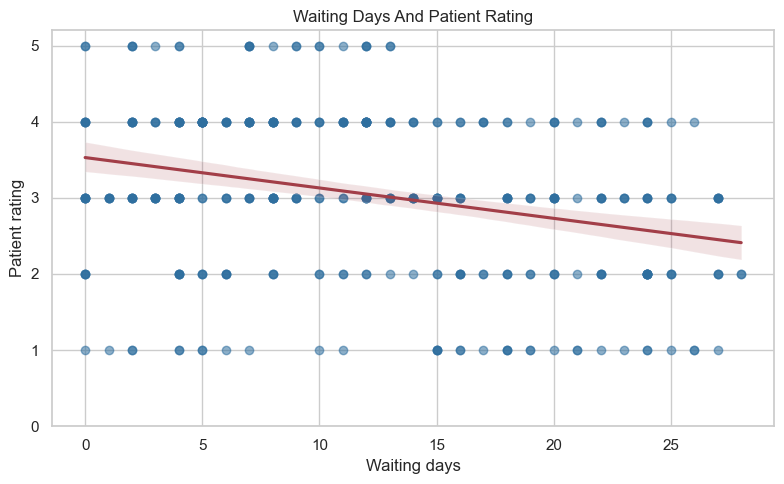

In [12]:
wait_rating_correlation = feedback_joined[["waiting_days", "rating"]].corr().iloc[0, 1]
correlation_result = pd.DataFrame({
    "metric": ["waiting_days_vs_rating_correlation"],
    "value": [wait_rating_correlation],
})
correlation_result.to_csv(TABLES / "waiting_rating_correlation.csv", index=False)

display(correlation_result.round(3))

plt.figure(figsize=(8, 5))
sns.regplot(
    data=feedback_joined,
    x="waiting_days",
    y="rating",
    scatter_kws={"alpha": 0.55, "color": "#2f6f9f"},
    line_kws={"color": "#a23e48"},
)
plt.title("Waiting Days And Patient Rating")
plt.xlabel("Waiting days")
plt.ylabel("Patient rating")
plt.ylim(0, 5.2)
plt.tight_layout()
plt.savefig(FIGURES / "waiting_days_vs_rating.png", dpi=150)
plt.show()

## 13. Referral Delay Analysis

This cell identifies which referral services have the highest open or delayed referral rate, then charts the same result.

,target_service,referrals,delayed_or_open,avg_days_open,max_days_open,delayed_or_open_rate
0,Cardiology,45,23,23.09,74,51.11
1,Community Nursing,53,25,27.70,73,47.17
5,Physiotherapy,38,17,25.47,75,44.74
2,Dermatology,42,16,23.24,71,38.10
3,Diagnostics,35,11,26.43,72,31.43
4,Mental Health,37,11,26.19,71,29.73


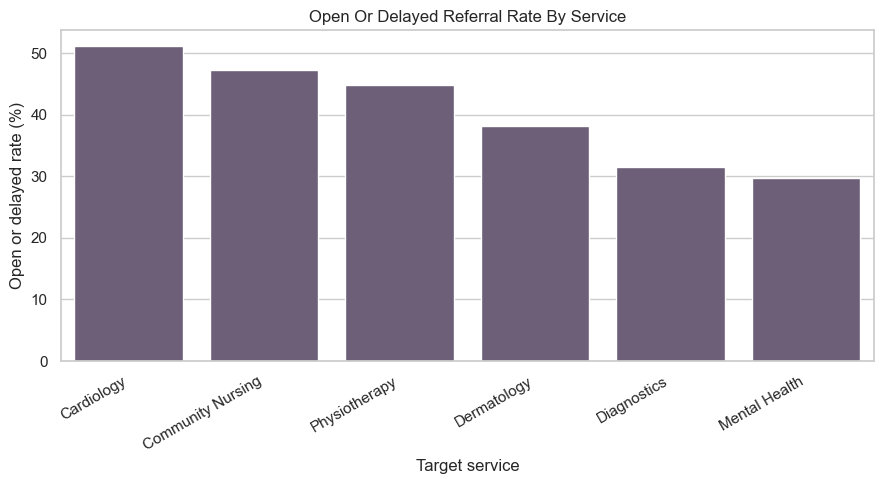

In [13]:
referral_by_service = (
    referrals.groupby("target_service", as_index=False)
    .agg(
        referrals=("referral_id", "count"),
        delayed_or_open=("delayed_or_open", "sum"),
        avg_days_open=("days_open", "mean"),
        max_days_open=("days_open", "max"),
    )
)
referral_by_service["delayed_or_open_rate"] = referral_by_service["delayed_or_open"] / referral_by_service["referrals"] * 100
referral_by_service = referral_by_service.sort_values("delayed_or_open_rate", ascending=False)
referral_by_service.to_csv(TABLES / "referral_by_service.csv", index=False)

display(referral_by_service.round(2))

plt.figure(figsize=(9, 5))
sns.barplot(data=referral_by_service, x="target_service", y="delayed_or_open_rate", color="#6c5b7b")
plt.title("Open Or Delayed Referral Rate By Service")
plt.xlabel("Target service")
plt.ylabel("Open or delayed rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "referral_delay_by_service.png", dpi=150)
plt.show()

## 14. Prescription Delay Analysis

This cell identifies prescription delay by clinic and shows the matching chart below the table.

,clinic_id,clinic_name,prescriptions,delayed_count,not_collected,avg_processing_days,delayed_rate
1,CL002,Green Park Health Centre,46,13,13,2.37,28.26
4,CL005,Hillview Medical Hub,78,18,21,2.35,23.08
2,CL003,Northgate Diagnostics,80,17,22,2.15,21.25
0,CL001,Riverside Clinic,66,14,22,2.27,21.21
3,CL004,Westbridge Community Clinic,64,12,23,2.50,18.75
5,CL006,Canal Walk Clinic,66,12,20,2.24,18.18


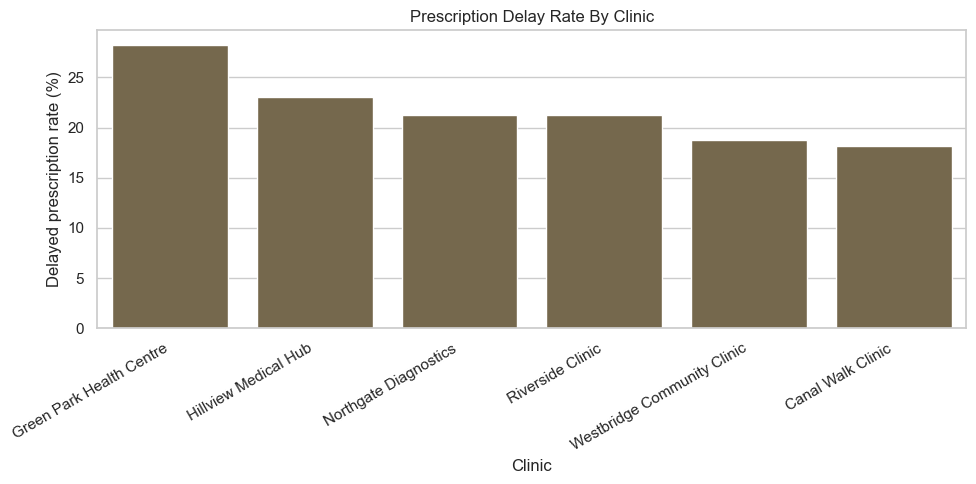

In [14]:
prescription_by_clinic = (
    prescriptions.merge(clinics[["clinic_id", "clinic_name"]], on="clinic_id", how="left")
    .groupby(["clinic_id", "clinic_name"], as_index=False)
    .agg(
        prescriptions=("prescription_id", "count"),
        delayed_count=("delayed_prescription", "sum"),
        not_collected=("collection_date", lambda s: s.isna().sum()),
        avg_processing_days=("processing_days", "mean"),
    )
)
prescription_by_clinic["delayed_rate"] = prescription_by_clinic["delayed_count"] / prescription_by_clinic["prescriptions"] * 100
prescription_by_clinic = prescription_by_clinic.sort_values("delayed_rate", ascending=False)
prescription_by_clinic.to_csv(TABLES / "prescription_by_clinic.csv", index=False)

display(prescription_by_clinic.round(2))

plt.figure(figsize=(10, 5))
sns.barplot(data=prescription_by_clinic, x="clinic_name", y="delayed_rate", color="#7c6a46")
plt.title("Prescription Delay Rate By Clinic")
plt.xlabel("Clinic")
plt.ylabel("Delayed prescription rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "prescription_delay_by_clinic.png", dpi=150)
plt.show()

## 15. Nurse Visit Problem Analysis

This cell checks nurse visits by clinic and places the related chart directly below the table.

,clinic_id,clinic_name,visits,problem_visits,avg_arrival_delay_min,avg_travel_distance_km,problem_visit_rate
0,CL001,Riverside Clinic,76,63,11.84,9.89,82.89
5,CL006,Canal Walk Clinic,51,37,12.35,8.77,72.55
3,CL004,Westbridge Community Clinic,83,60,13.01,8.94,72.29
2,CL003,Northgate Diagnostics,30,20,9.00,9.16,66.67
4,CL005,Hillview Medical Hub,33,22,15.91,10.34,66.67
1,CL002,Green Park Health Centre,27,16,10.56,10.13,59.26


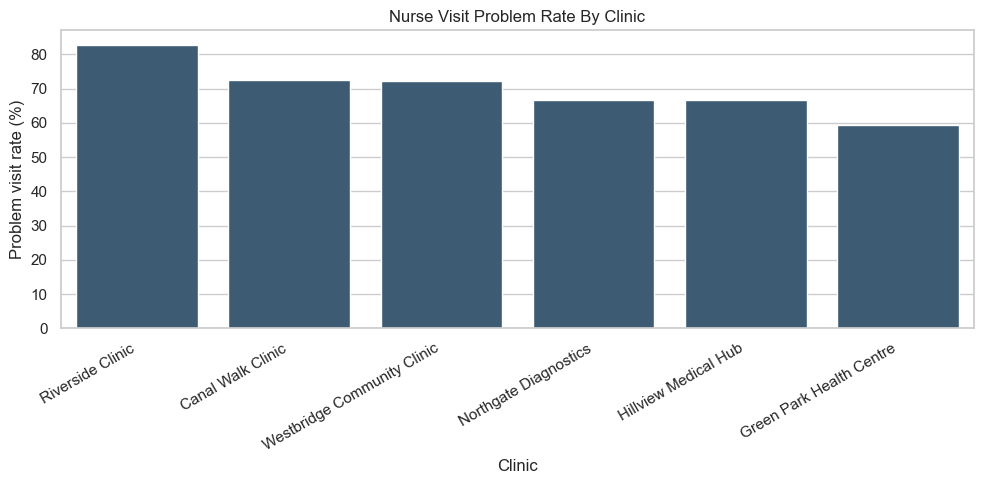

In [15]:
nurse_visit_by_clinic = (
    nurse_visits.merge(clinics[["clinic_id", "clinic_name"]], on="clinic_id", how="left")
    .groupby(["clinic_id", "clinic_name"], as_index=False)
    .agg(
        visits=("visit_id", "count"),
        problem_visits=("problem_visit", "sum"),
        avg_arrival_delay_min=("arrival_delay_min", "mean"),
        avg_travel_distance_km=("travel_distance_km", "mean"),
    )
)
nurse_visit_by_clinic["problem_visit_rate"] = nurse_visit_by_clinic["problem_visits"] / nurse_visit_by_clinic["visits"] * 100
nurse_visit_by_clinic = nurse_visit_by_clinic.sort_values("problem_visit_rate", ascending=False)
nurse_visit_by_clinic.to_csv(TABLES / "nurse_visit_by_clinic.csv", index=False)

display(nurse_visit_by_clinic.round(2))

plt.figure(figsize=(10, 5))
sns.barplot(data=nurse_visit_by_clinic, x="clinic_name", y="problem_visit_rate", color="#355c7d")
plt.title("Nurse Visit Problem Rate By Clinic")
plt.xlabel("Clinic")
plt.ylabel("Problem visit rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "nurse_visit_problem_by_clinic.png", dpi=150)
plt.show()

## 16. Staff And Clinic Capacity Snapshot

This cell combines staff data and clinic capacity to support the operational analysis.

,clinic_id,clinic_name,town,clinic_type,capacity_per_day,staff_count,staff_records,total_weekly_hours,avg_experience_years
0,CL001,Riverside Clinic,Ealing,General Practice,85,18,13,318.0,9.69
1,CL002,Green Park Health Centre,Hounslow,General Practice,70,15,14,416.5,10.64
2,CL003,Northgate Diagnostics,Uxbridge,Diagnostics,55,12,5,124.0,8.20
3,CL004,Westbridge Community Clinic,Southall,Community Care,60,14,12,342.0,8.67
4,CL005,Hillview Medical Hub,Acton,Mixed Service,75,16,9,272.0,8.56
5,CL006,Canal Walk Clinic,Brentford,General Practice,50,9,7,178.0,8.57


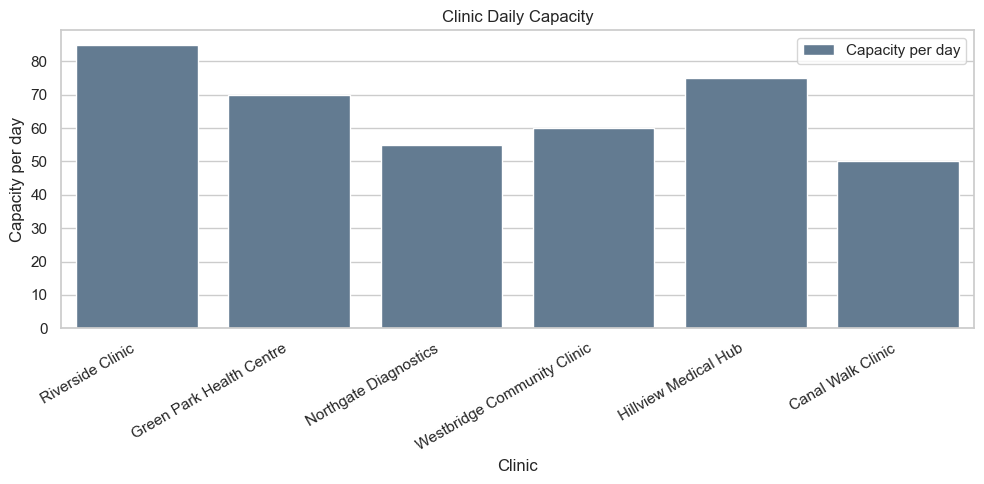

In [16]:
staff_summary = (
    staff.groupby("clinic_id", as_index=False)
    .agg(
        staff_records=("staff_id", "count"),
        total_weekly_hours=("weekly_hours", "sum"),
        avg_experience_years=("experience_years", "mean"),
    )
)

clinic_capacity = clinics.merge(staff_summary, on="clinic_id", how="left")
clinic_capacity.to_csv(TABLES / "clinic_capacity_snapshot.csv", index=False)

display(clinic_capacity.round(2))

plt.figure(figsize=(10, 5))
sns.barplot(data=clinic_capacity, x="clinic_name", y="capacity_per_day", color="#5b7c99", label="Capacity per day")
plt.title("Clinic Daily Capacity")
plt.xlabel("Clinic")
plt.ylabel("Capacity per day")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "clinic_capacity_by_clinic.png", dpi=150)
plt.show()

## 17. Patient Segment Risk

This cell compares appointment outcomes by digital access and long-term condition to support patient-focused interpretation.

In [17]:
appointment_patient = appointments.merge(
    patients[["patient_id", "digital_access", "long_term_condition", "age"]],
    on="patient_id",
    how="left",
)

segment_risk = (
    appointment_patient.groupby(["digital_access", "long_term_condition"], dropna=False, as_index=False)
    .agg(
        appointments=("appointment_id", "count"),
        bad_outcomes=("bad_outcome", "sum"),
        avg_waiting_days=("waiting_days", "mean"),
        avg_age=("age", "mean"),
    )
)
segment_risk["bad_outcome_rate"] = segment_risk["bad_outcomes"] / segment_risk["appointments"] * 100
segment_risk = segment_risk.sort_values("bad_outcome_rate", ascending=False)
segment_risk.to_csv(TABLES / "patient_segment_risk.csv", index=False)
display(segment_risk.round(2))

,digital_access,long_term_condition,appointments,bad_outcomes,avg_waiting_days,avg_age,bad_outcome_rate
7,Low,Diabetes,23,13,11.35,62.78,56.52
15,Medium,Hypertension,35,19,11.14,53.74,54.29
13,Medium,Diabetes,43,19,11.95,45.05,44.19
4,High,Multiple,15,6,13.47,63.73,40.00
11,Low,NaN,59,20,13.47,54.98,33.90
5,High,NaN,125,42,12.88,58.86,33.60
0,High,Asthma,82,25,13.77,48.57,30.49
8,Low,Heart condition,10,3,16.20,62.10,30.00
3,High,Hypertension,48,14,11.94,63.02,29.17
16,Medium,Multiple,26,7,12.85,55.00,26.92


## 18. Digital Interaction Analysis

This cell uses the digital interaction dataset to check which event types and communication channels appear most often. This links the Python analysis to the case study problem of fragmented digital service records.

,event_type,events
0,status_changed,137
1,message_received,125
2,staff_note,123
3,reminder_sent,117
4,patient_reply,115
5,escalation,102


,channel,events
0,mobile_app,200
1,web_form,184
2,phone,182
3,SMS,153


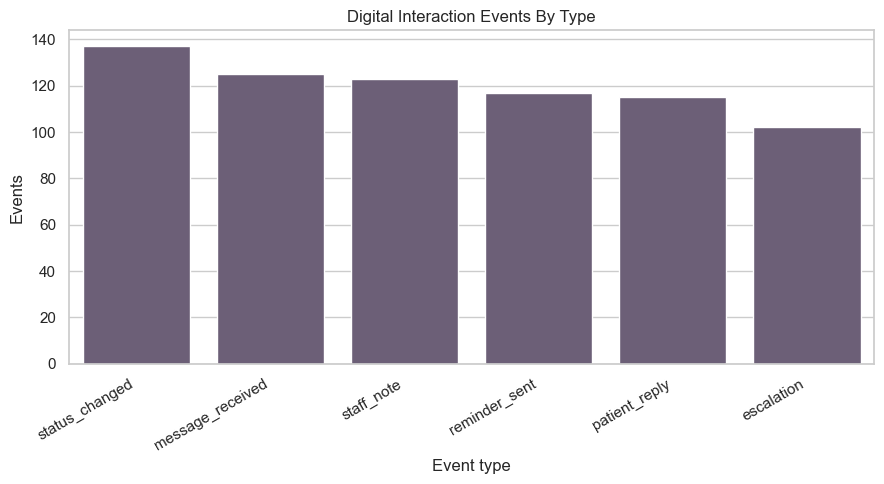

In [18]:
digital["timestamp"] = pd.to_datetime(digital["timestamp"])

event_type_counts = (
    digital["event_type"]
    .value_counts()
    .rename_axis("event_type")
    .reset_index(name="events")
)
channel_counts = (
    digital["channel"]
    .value_counts()
    .rename_axis("channel")
    .reset_index(name="events")
)

event_type_counts.to_csv(TABLES / "digital_event_type_counts.csv", index=False)
channel_counts.to_csv(TABLES / "digital_channel_counts.csv", index=False)

display(event_type_counts)
display(channel_counts)

plt.figure(figsize=(9, 5))
sns.barplot(data=event_type_counts, x="event_type", y="events", color="#6c5b7b")
plt.title("Digital Interaction Events By Type")
plt.xlabel("Event type")
plt.ylabel("Events")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "digital_event_type_counts.png", dpi=150)
plt.show()

## 19. Combined Clinic Risk Snapshot

This cell combines the main clinic risk indicators and shows the heatmap directly below the table.

,clinic_id,clinic_name,bad_outcome_rate,avg_waiting_days,avg_rating,complaint_rate,delayed_rate,problem_visit_rate,risk_score
0,CL006,Canal Walk Clinic,40.94,13.09,2.79,100.0,18.18,72.55,3.58
2,CL003,Northgate Diagnostics,31.54,12.02,3.01,100.0,21.25,66.67,3.17
1,CL001,Riverside Clinic,36.22,12.56,3.23,100.0,21.21,82.89,3.08
3,CL002,Green Park Health Centre,28.12,13.80,3.02,100.0,28.26,59.26,2.92
4,CL004,Westbridge Community Clinic,27.35,12.32,3.13,100.0,18.75,72.29,2.42
5,CL005,Hillview Medical Hub,21.36,13.48,3.21,100.0,23.08,66.67,2.33


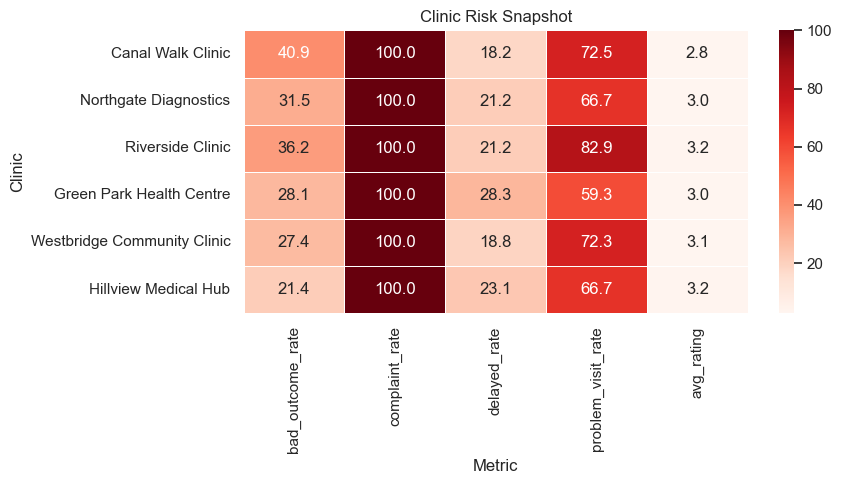

In [19]:
clinic_risk = (
    clinic_performance[["clinic_id", "clinic_name", "bad_outcome_rate", "avg_waiting_days"]]
    .merge(feedback_by_clinic[["clinic_id", "avg_rating", "complaint_rate"]], on="clinic_id", how="left")
    .merge(prescription_by_clinic[["clinic_id", "delayed_rate"]], on="clinic_id", how="left")
    .merge(nurse_visit_by_clinic[["clinic_id", "problem_visit_rate"]], on="clinic_id", how="left")
)
clinic_risk["risk_score"] = (
    clinic_risk["bad_outcome_rate"].rank(pct=True)
    + clinic_risk["complaint_rate"].rank(pct=True)
    + clinic_risk["delayed_rate"].rank(pct=True)
    + clinic_risk["problem_visit_rate"].rank(pct=True)
    + clinic_risk["avg_rating"].rank(pct=True, ascending=False)
)
clinic_risk = clinic_risk.sort_values("risk_score", ascending=False)
clinic_risk.to_csv(TABLES / "clinic_risk_snapshot.csv", index=False)

display(clinic_risk.round(2))

heatmap_data = clinic_risk.set_index("clinic_name")[[
    "bad_outcome_rate", "complaint_rate", "delayed_rate", "problem_visit_rate", "avg_rating"
]]

plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="Reds", linewidths=0.5)
plt.title("Clinic Risk Snapshot")
plt.xlabel("Metric")
plt.ylabel("Clinic")
plt.tight_layout()
plt.savefig(FIGURES / "clinic_risk_heatmap.png", dpi=150)
plt.show()